Visualizing LFP patterns per session (works in ephys2/ephys3 environment)

In [3]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/FreelyMovingEphys')
import fmEphys as fme
import os, json
import netCDF4 as nc
import numpy as np
import pandas as pd
import xarray as xr
import scipy as sp
import scipy.interpolate
from tqdm import tqdm
from glob import glob
import matplotlib 
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import pyplot as plt
from matplotlib import transforms
from matplotlib import cm
matplotlib.rcParams.update({'font.size': 10})
import cv2
from datetime import datetime



def butter_bandpass(lfp, lowcut=1, highcut=300, fs=30000, order=5):
    """ Apply bandpass filter to ephys LFP along time dimension.

    Parameters
    ----------
    lfp : np.array
        Ephys LFP with shape (time, channel).
    lowcut : int
        Low end of frequency cut off.
    highcut : int
        High end of frequency cut off.
    fs : int
        Sample rate.
    order : int
        Order of filter.

    Returns
    -------
    filt : np.array
        Filtered data with shape (time, channel).

    """

    # Nyquist frequency
    nyq = 0.5 * fs 

    # Low cutoff
    low = lowcut / nyq

    # High cutoff
    high = highcut / nyq

    # Apply butterworth filter.
    sos = scipy.signal.butter(order,
                                [low, high],
                                btype='bandpass', output='sos')
    
    # Apply filter forward and backward to avoid phase shift.
    filt = scipy.signal.sosfiltfilt(sos, lfp, axis=0)

    return filt

def read_timestamp_series(s):
    """ Read timestamps as a pd.Series and format time.

    Parameters
    ----------
    s : pd.Series
        Timestamps as a Series. Expected to be formated as
        hours:minutes:seconds.microsecond

    Returns
    -------
    output_time : np.array
        Returned as the number of seconds that have passed since the
        previous midnight, with microescond precision, e.g. 700.000000

    """

    # Expected string format for timestamps.
    fmt = '%H:%M:%S.%f'

    output_time = []

    if s.dtype != np.float64:

        for current_time in s:

            str_time = str(current_time).strip()

            try:
                t = datetime.strptime(str_time, fmt)

            except ValueError as v:
                # If the string had unexpected characters (too much precision) for
                # one timepoint, drop the extra characters.

                ulr = len(v.args[0].partition('unconverted data remains: ')[2])
                
                if ulr:
                    str_time = str_time[:-ulr]
            
            try:
                output_time.append(
                        (datetime.strptime(str_time, '%H:%M:%S.%f')
                            - datetime.strptime('00:00:00.000000', '%H:%M:%S.%f')
                            ).total_seconds())

            except ValueError:
                output_time.append(np.nan)

        output_time = np.array(output_time)

    else:
        output_time = s.values

    return output_time

def interp_timestamps(camT, use_medstep=False):
    """ Interpolate timestamps for double the number of
    frames. Compensates for video deinterlacing.
    
    Parameters
    ----------
    camT : np.array
        Camera timestamps aquired at 30Hz
    use_medstep : bool
        When True, the median diff(camT) will be used as the timestep
        in interpolation. If False, the timestep between each frame
        will be used instead.

    Returns
    -------
    camT_out : np.array
        Timestamps of camera interpolated so that there are twice the
        number of timestamps in the array. Each timestamp in camT will
        be replaced by two, set equal distances from the original.

    """

    camT_out = np.zeros(np.size(camT, 0)*2)
    medstep = np.nanmedian(np.diff(camT, axis=0))

    if use_medstep:
        
        # Shift each deinterlaced frame by 0.5 frame periods
        # forward/backwards assuming a constant framerate

        camT_out[::2] = camT - 0.25 * medstep
        camT_out[1::2] = camT + 0.25 * medstep
    
    elif not use_medstep:

        # Shift each deinterlaced frame by the actual time between
        # frames. If a camera frame was dropped, this approach will
        # be more accurate than `medstep` above.
        
        steps = np.diff(camT, axis=0, append=camT[-1]+medstep)
        camT_out[::2] = camT
        camT_out[1::2] = camT + 0.5 * steps

    return camT_out


def read_timestamp_file(timestamp_path,position_data_length=None,
                        force_timestamp_shift=False):
    """ Read timestamps from a .csv file.

    Parameters
    ----------
    position_data_length : None or int
        Number of timesteps in data from deeplabcut. This is used to
        determine whether or not the number of timestamps is too short
        for the number of video frames.
        Eyecam and Worldcam will have half the number of timestamps as
        the number of frames, since they are aquired as an interlaced
        video and deinterlaced in analysis. To fix this, timestamps need
        to be interpolated.
    force_timestamp_shift : bool
        When True, the timestamps will be interpolated regardless of
        whether or not the number of timestamps is too short for the
        number of frames. Default is False.

    Returns
    -------
    camT : np.array
        Timestamps of camera interpolated so that there are twice the
        number of timestamps in the array than there were in the provided
        csv file.

    """

    # Read data and set up format
    s = pd.read_csv(timestamp_path, encoding='utf-8',
                    engine='c', header=None).squeeze()
    
    # If the csv file has a header name for the column, (which is
    # is the int 0 for some early recordings), remove it.
    if s[0] == 0:
        s = s[1:]
    
    # Read the timestamps as a series and format them
    camT = read_timestamp_series(s)
    
    # Auto check if vids were deinterlaced
    if position_data_length is not None:

        if position_data_length > len(camT):

            # If the number of timestamps is too short for the number
            # of frames, interpolate the timestamps.

            camT = interp_timestamps(camT, use_medstep=False)
    
    # Force the times to be shifted if the user is sure it should be done
    if force_timestamp_shift is True:

        camT = interp_timestamps(camT, use_medstep=False)
    
    return camT


revchecker_window_start = 0.1  # sec
revchecker_window_end = 0.5 # sec
ephys_samprate = 30000
colors = plt.cm.jet(np.linspace(0,1,32))

# Open channel map file
with open(r'C:\Users\nlab\Documents\GitHub\FreelyMovingEphys\fmEphys\utils\probes.json' ) as fp:
    all_maps = json.load(fp)


Import dataset 

In [9]:

dates_all = '022823'  #Session date
animal_all = 'J637NC' #Animal ID
probes_all = 'DB_P128_6' #Probe ID

Process revchecker world video / find reverse onset / calculate LFP

In [4]:
#session_date = dates_all
#animal_ID = animal_all
#session_ID = 'hf4_revchecker'
#Rig_ID = 'Rig2'

#import reverse checkerboard session 

ephys_csv_filepath = r"\\goeppert\Vol2\mike\recordings\032025\CK77LT\hf1_revchecker\032025_CK77LT_doi_Rig2_hf1_revchecker_Ephys_BonsaiBoardTS.csv"
hf_rc_ephys_bin = r"\\goeppert\Vol2\mike\recordings\032025\CK77LT\hf1_revchecker\032025_CK77LT_doi_Rig2_hf1_revchecker_Ephys.bin"
ephys_time = read_timestamp_file(ephys_csv_filepath)
ephysT0 = ephys_time[0]

# Get channel map for this probe
ch_map = all_maps[probes_all]['map']
num_ch = all_maps[probes_all]['nCh']

# Set up data types to read binary file into
dtypes = np.dtype([('ch'+str(i),np.uint16) for i in range(0,num_ch)])
ephys = pd.DataFrame(np.fromfile(hf_rc_ephys_bin, dtypes, -1, ''))

#import reverse checkerboard video

hf_rc_world_data = xr.open_dataset('/media/niell_lab/Seagate Expansion Drive/freely moving ephys/shelby_sc_project/'+str(session_date)+'/'+str(animal_ID)+'/'+str(session_ID)+'/'+str(session_date)+'_'+str(animal_ID)+'_control_'+str(Rig_ID)+'_'+str(session_ID)+'_world.nc')
world_vid_raw = hf_rc_world_data.WORLD_video.astype(np.uint8).values

# Raw video size
sz = world_vid_raw.shape

# Resize if size is larger than the target 60x80
dwnsmpl = 0.5

if sz[1]>120:

    rc_world_vid = np.zeros((sz[0],
                                int(sz[1]*dwnsmpl),
                                int(sz[2]*dwnsmpl)), dtype='uint8')
    
    for f in range(sz[0]):
        rc_world_vid[f,:,:] = cv2.resize(world_vid_raw[f,:,:],
                                            (int(sz[2]*dwnsmpl),
                                            int(sz[1]*dwnsmpl)))
else:
    rc_world_vid = world_vid_raw.copy()

rc_worldT = hf_rc_world_data.timestamps.data.copy()
rc_worldT = rc_worldT - ephysT0



# Remap with known order of channels
ephys = ephys.iloc[:,[i-1 for i in list(ch_map)]]
lfp_ephys  = ephys

# subtract off average for each channel, then apply bandpass filter
ephys_center_sub = lfp_ephys - np.mean(lfp_ephys, 0)
filt_ephys = butter_bandpass(ephys_center_sub, order=6)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.85)

num_frames = np.size(rc_world_vid, 0)
vid_width = np.size(rc_world_vid, 1)
vid_height = np.size(rc_world_vid, 2)

kmeans_input = rc_world_vid.reshape(num_frames, vid_width*vid_height)

_, labels, _ = cv2.kmeans(kmeans_input.astype(np.float32),
                            2,
                            None,
                            criteria,
                            10,
                            cv2.KMEANS_RANDOM_CENTERS)

label_diff = np.diff(np.ndarray.flatten(labels))

# Need abs because reversing back will be -1
revind = list(abs(label_diff))


# Get response of each channel centered around time of checkerboard reversal
all_resp = np.zeros([np.size(filt_ephys, 1),
                        np.sum(revind),
                        len(list(set(np.arange(1-revchecker_window_start,
                                            1+revchecker_window_end,
                                            1/ephys_samprate))))])

true_rev_index = 0

for rev_index, rev_label in tqdm(enumerate(revind)):
    
    if rev_label == True and rc_worldT[rev_index] > 1:
        
        for ch_num in range(np.size(filt_ephys, 1)):
            
            # Index of ephys data to start window with, aligned to set time before checkerboard will reverse
            bin_start = int((rc_worldT[rev_index]-revchecker_window_start)*ephys_samprate)
            
            # Index of ephys data to end window with, aligned to time after checkerboard reversed
            bin_end = int((rc_worldT[rev_index]+revchecker_window_end)*ephys_samprate)
            
            # Index into the filtered ephys data and store each trace for this channel of the probe
            if bin_end < np.size(filt_ephys, 0): # make sure it's a possible range
                all_resp[ch_num, true_rev_index] = filt_ephys[bin_start:bin_end, ch_num]
        
        true_rev_index = true_rev_index + 1

# Mean of responses within each channel
rev_resp_mean = np.mean(all_resp, 1)

FileNotFoundError: [Errno 2] No such file or directory: '\\goeppert\\Vol2\\mike\recordings\x1a025\\CK77LT\\hf1_revchecker\x1a025_CK77LT_doi_Rig2_hf1_revchecker_Ephys_BonsaiBoardTS.csv'

Visualization of the raw LFP & median filtered LFP 

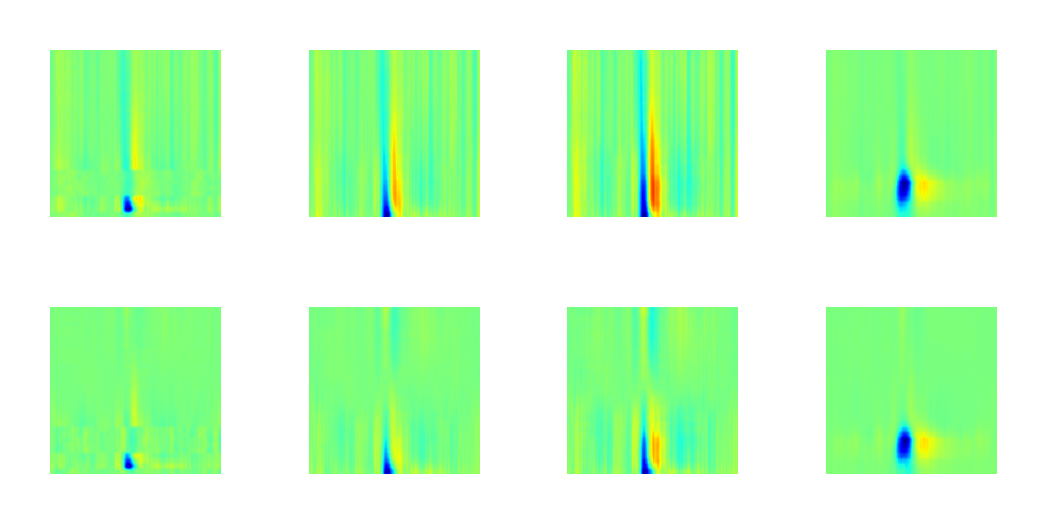

In [11]:

fig = plt.figure(figsize=(4,8), dpi=500) #Figure size/resolution
fig.tight_layout()
grid = plt.GridSpec(36, 36, figure=fig, wspace = 0.05, hspace = 0.05)
ax = plt.subplot(grid[0:2, 0:4])
ax.axis("off")
c_range = np.nanmax(abs(rev_resp_mean[0:32]))
ax.imshow(rev_resp_mean[0:32], cmap = 'jet', vmin = -1*c_range, vmax = c_range)
ax.set_aspect('auto')

ax = plt.subplot(grid[3:5, 0:4])
ax.axis("off")
c_range = np.nanmax(abs(rev_resp_mean[0:32]-np.nanmedian(rev_resp_mean[0:32],0)))
ax.imshow(rev_resp_mean[0:32]-np.nanmedian(rev_resp_mean[0:32],0), cmap = 'jet', vmin = -1*c_range, vmax = c_range)
ax.set_aspect('auto')


ax = plt.subplot(grid[0:2, 6:10])
c_range = np.nanmax(abs(rev_resp_mean[32:64]))
ax.imshow(rev_resp_mean[32:64], cmap = 'jet', vmin = -1*c_range, vmax = c_range)
ax.set_aspect('auto')
ax.axis("off")


ax = plt.subplot(grid[3:5, 6:10])
ax.axis("off")
c_range = np.nanmax(abs(rev_resp_mean[32:64]-np.nanmedian(rev_resp_mean[32:64],0)))
ax.imshow(rev_resp_mean[32:64]-np.nanmedian(rev_resp_mean[32:64],0), cmap = 'jet', vmin = -1*c_range, vmax = c_range)
ax.set_aspect('auto')

ax = plt.subplot(grid[0:2, 12:16])
c_range = np.nanmax(abs(rev_resp_mean[64:96]))
ax.imshow(rev_resp_mean[64:96], cmap = 'jet', vmin = -1*c_range, vmax = c_range)
ax.set_aspect('auto')
ax.axis("off")

ax = plt.subplot(grid[3:5, 12:16])
ax.axis("off")
c_range = np.nanmax(abs(rev_resp_mean[64:96]-np.nanmedian(rev_resp_mean[64:96],0)))
ax.imshow(rev_resp_mean[64:96]-np.nanmedian(rev_resp_mean[64:96],0), cmap = 'jet', vmin = -1*c_range, vmax = c_range)
ax.set_aspect('auto')

ax = plt.subplot(grid[0:2, 18:22])
c_range = np.nanmax(abs(rev_resp_mean[96:128]))
ax.imshow(rev_resp_mean[96:128], cmap = 'jet', vmin = -1*c_range, vmax = c_range)
ax.set_aspect('auto')
ax.axis("off")

ax = plt.subplot(grid[3:5, 18:22])
ax.axis("off")
c_range = np.nanmax(abs(rev_resp_mean[96:128]-np.nanmedian(rev_resp_mean[96:128],0)))
ax.imshow(rev_resp_mean[96:128]-np.nanmedian(rev_resp_mean[96:128],0), cmap = 'jet', vmin = -1*c_range, vmax = c_range)
ax.set_aspect('auto')
        

Visualizing LFP patterns by waveforms

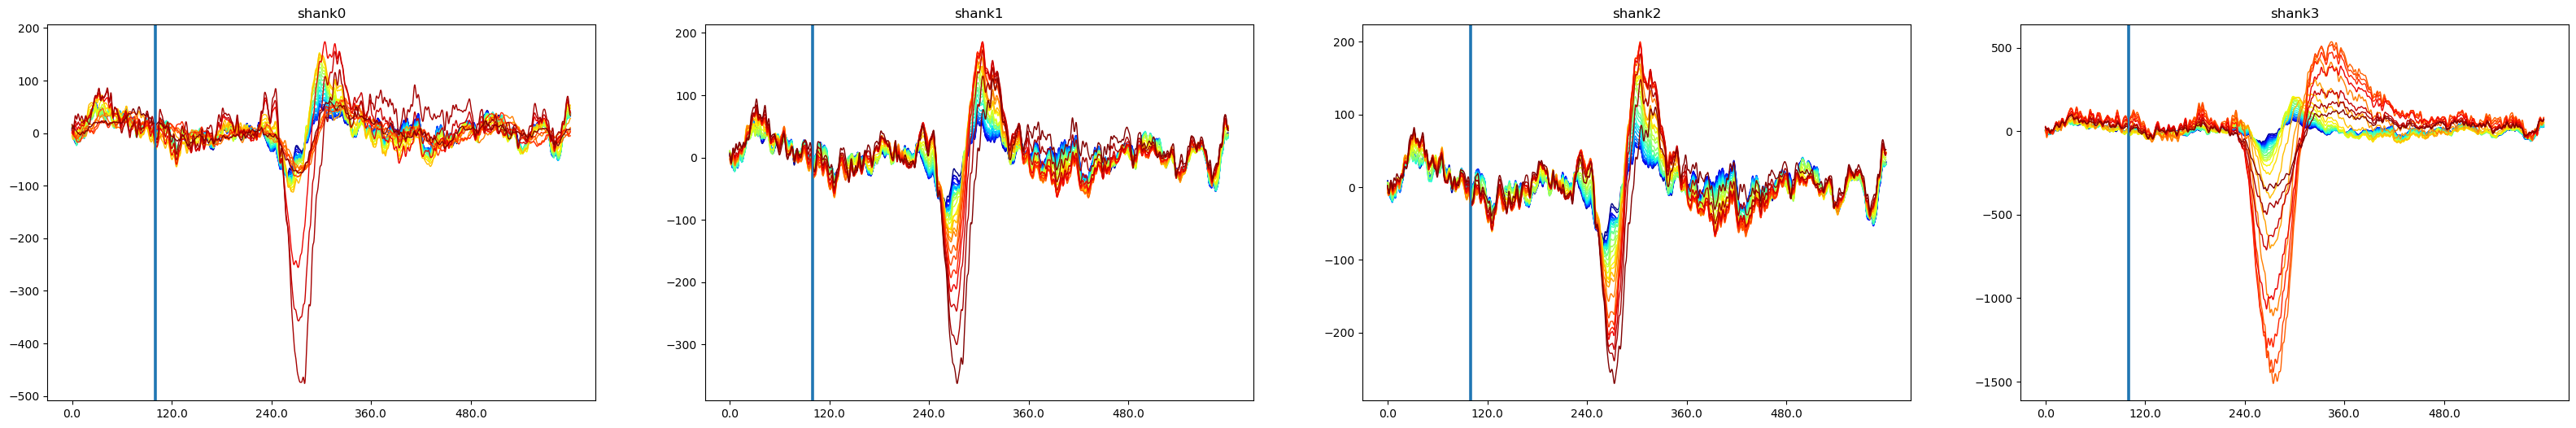

In [12]:
plt.subplots(1,4 ,figsize=(40,6))

for ch_num in np.arange(0,128):

    if ch_num < 32:
        plt.subplot(1,4,1)
        plt.plot(rev_resp_mean[ch_num], color=colors[ch_num], linewidth=1)
        plt.title('shank0')
        plt.axvline(x=(0.1*ephys_samprate))
        plt.xticks(np.arange(0,18000,18000/5), np.arange(0,600,600/5))
    
    elif 32 <= ch_num < 64:

        plt.subplot(1,4,2)
        plt.plot(rev_resp_mean[ch_num], color=colors[ch_num-32], linewidth=1)
        plt.title('shank1')
        plt.axvline(x=(0.1*ephys_samprate))
        plt.xticks(np.arange(0,18000,18000/5), np.arange(0,600,600/5))
    
    elif 64 <= ch_num < 96:

        plt.subplot(1,4,3)
        plt.plot(rev_resp_mean[ch_num], color=colors[ch_num-64], linewidth=1)
        plt.title('shank2')
        plt.axvline(x=(0.1*ephys_samprate))
        plt.xticks(np.arange(0,18000,18000/5), np.arange(0,600,600/5))
    
    elif 96 <= ch_num < 128:

        plt.subplot(1,4,4)
        plt.plot(rev_resp_mean[ch_num], color=colors[ch_num-96], linewidth=1)
        plt.title('shank3')
        plt.axvline(x=(0.1*ephys_samprate))
        plt.xticks(np.arange(0,18000,18000/5), np.arange(0,600,600/5))